# Intervalos de confiança e bootstrap

**Tema:** Estatística › Inferência e Estimação

Este notebook tem dois objetivos, e o primeiro é conceitual:

1. Mostrar **visualmente** o que um intervalo de confiança de 95% promete — e
   demolir a interpretação errada que quase todo mundo usa.
2. Ensinar o **bootstrap**, que dá intervalo para qualquer estatística, mesmo
   aquelas sem fórmula fechada.

> **A frase que você deve conseguir defender ao final:** "95% de confiança" é
> uma propriedade do **procedimento** repetido, não uma probabilidade sobre o
> intervalo específico que você calculou.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

rng = np.random.default_rng(555)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3
AZUL, VERDE, VERMELHO, ROXO, AMBAR = "#1F5C8B", "#1E6B4F", "#9C2B2B", "#5B3E86", "#8A6100"
print("pronto")

pronto


## 1. O que 95% de confiança significa, visto de fora

Vamos fazer o que na vida real é impossível: repetir o experimento 100 vezes,
**sabendo** o valor verdadeiro, e desenhar todos os intervalos.

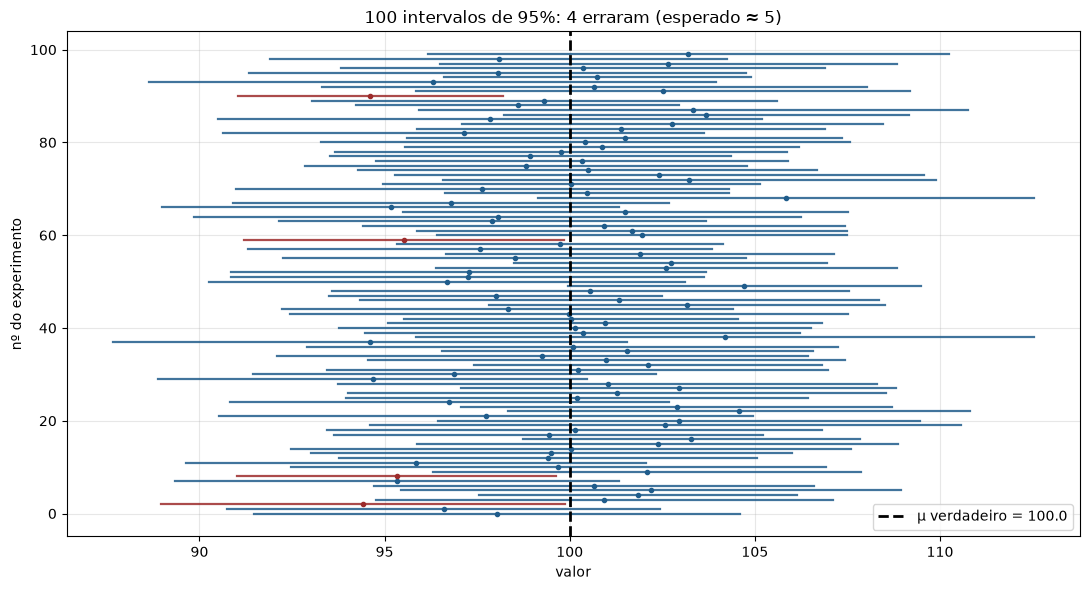

Cobertura observada: 96.0%  (nominal: 95,0%)

Repare: cada intervalo individual OU contém μ OU não contém.
Não há 'probabilidade' nisso — o μ é uma constante fixa.
O que tem 95% de garantia é a TAXA DE ACERTO do procedimento.


In [2]:
MU_VERDADEIRO, SIGMA = 100.0, 15.0
n, n_experimentos = 25, 100

amostras = rng.normal(MU_VERDADEIRO, SIGMA, size=(n_experimentos, n))
medias = amostras.mean(axis=1)
erros_padrao = amostras.std(axis=1, ddof=1) / np.sqrt(n)
t_critico = stats.t.ppf(0.975, df=n - 1)
inferior = medias - t_critico * erros_padrao
superior = medias + t_critico * erros_padrao
contem = (inferior <= MU_VERDADEIRO) & (MU_VERDADEIRO <= superior)

fig, ax = plt.subplots(figsize=(11, 6))
for i in range(n_experimentos):
    cor = AZUL if contem[i] else VERMELHO
    ax.plot([inferior[i], superior[i]], [i, i], lw=1.6, color=cor, alpha=0.85)
    ax.plot(medias[i], i, "o", ms=3, color=cor)
ax.axvline(MU_VERDADEIRO, color="black", lw=2, ls="--",
           label=f"μ verdadeiro = {MU_VERDADEIRO}")
ax.set_xlabel("valor")
ax.set_ylabel("nº do experimento")
ax.set_title(f"100 intervalos de 95%: {(~contem).sum()} erraram "
             f"(esperado ≈ 5)")
ax.legend()
plt.tight_layout()
plt.show()

print(f"Cobertura observada: {contem.mean():.1%}  (nominal: 95,0%)")
print()
print("Repare: cada intervalo individual OU contém μ OU não contém.")
print("Não há 'probabilidade' nisso — o μ é uma constante fixa.")
print("O que tem 95% de garantia é a TAXA DE ACERTO do procedimento.")

> **Se o que você quer dizer é "há 95% de chance de $\theta$ estar aqui", você
> quer um intervalo bayesiano de credibilidade**, não um intervalo de
> confiança. Os dois frequentemente coincidem numericamente, mas significam
> coisas diferentes. Isso é o tema do módulo 05.

## 2. Cobertura real vs. nominal: nem todo IC cumpre o que promete

Um intervalo "de 95%" só vale se sua cobertura real for 95%. Vamos auditar
quatro métodos para proporções — inclusive o que todo mundo usa.

COBERTURA REAL de intervalos nominais de 95% (n = 300)

método  Agresti-Coull  Clopper-Pearson (exato)  Wald (o do livro-texto)  Wilson
p                                                                              
0.005            98.2                     98.1                     77.7    93.4
0.020            97.9                     96.4                     93.5    94.2
0.050            95.5                     96.7                     93.1    95.3
0.200            94.6                     95.9                     94.7    95.2
0.500            94.3                     95.6                     94.1    94.5


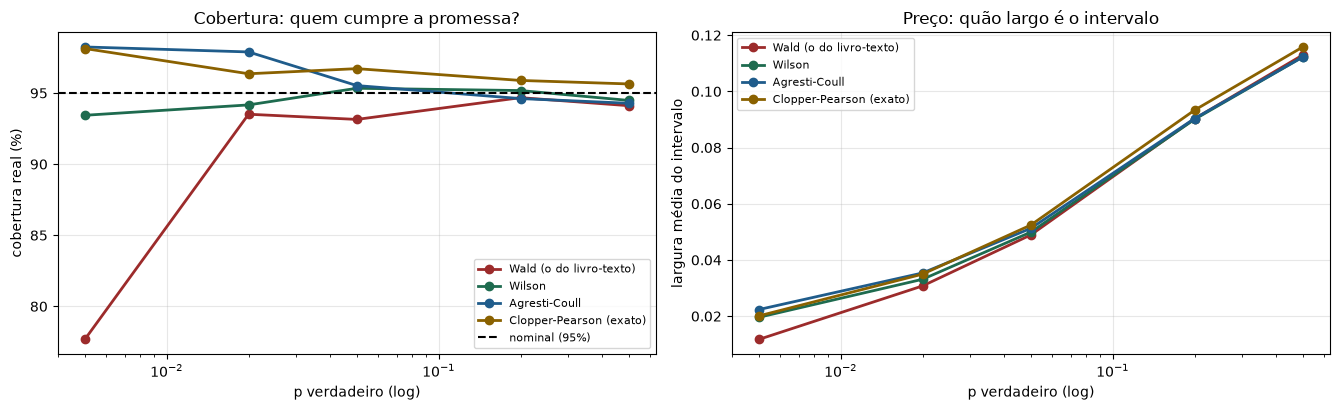

In [3]:
from statsmodels.stats.proportion import proportion_confint

def mede_cobertura(p_verdadeiro, n, metodo, n_sim=20_000):
    """Fração de intervalos que realmente contêm o p verdadeiro."""
    sucessos = rng.binomial(n, p_verdadeiro, size=n_sim)
    lo, hi = proportion_confint(sucessos, n, alpha=0.05, method=metodo)
    dentro = (lo <= p_verdadeiro) & (p_verdadeiro <= hi)
    largura = np.mean(hi - lo)
    return dentro.mean(), largura


metodos = {"normal": "Wald (o do livro-texto)", "wilson": "Wilson",
           "agresti_coull": "Agresti-Coull", "beta": "Clopper-Pearson (exato)"}
ps = [0.5, 0.2, 0.05, 0.02, 0.005]
N_FIXO = 300

linhas = []
for chave, nome in metodos.items():
    for p in ps:
        cob, larg = mede_cobertura(p, N_FIXO, chave)
        linhas.append({"método": nome, "p": p, "cobertura": cob, "largura média": larg})
cobertura = pd.DataFrame(linhas)

tabela_cob = cobertura.pivot(index="p", columns="método", values="cobertura")
print(f"COBERTURA REAL de intervalos nominais de 95% (n = {N_FIXO})\n")
print((tabela_cob * 100).round(1).to_string())

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13.5, 4.2))
for nome, cor in zip(metodos.values(), [VERMELHO, VERDE, AZUL, AMBAR]):
    sub = cobertura[cobertura["método"] == nome]
    ax1.plot(sub["p"], sub["cobertura"] * 100, "o-", lw=2, label=nome, color=cor)
    ax2.plot(sub["p"], sub["largura média"], "o-", lw=2, label=nome, color=cor)
ax1.axhline(95, ls="--", color="black", lw=1.5, label="nominal (95%)")
ax1.set_xscale("log")
ax1.set_xlabel("p verdadeiro (log)")
ax1.set_ylabel("cobertura real (%)")
ax1.set_title("Cobertura: quem cumpre a promessa?")
ax1.legend(fontsize=8)
ax2.set_xscale("log")
ax2.set_xlabel("p verdadeiro (log)")
ax2.set_ylabel("largura média do intervalo")
ax2.set_title("Preço: quão largo é o intervalo")
ax2.legend(fontsize=8)
plt.tight_layout()
plt.show()

Olhe a coluna do **Wald** para $p$ pequeno. A cobertura desaba muito abaixo dos
95% prometidos: o intervalo é estreito demais e mente sobre a própria precisão.

> **No mercado:** conversões raras (compra de plano anual, upgrade, fraude)
> vivem justamente na região onde o Wald falha. Times declaram vitória em
> testes A/B com base num intervalo que na verdade tem cobertura de 80%. A
> correção custa um argumento: `method="wilson"`.

## 3. Bootstrap: intervalo para qualquer estatística

A pergunta motivadora: **qual é o erro-padrão da mediana?** Ou do p95? Ou do
coeficiente de Gini? Não há fórmula simples. O bootstrap resolve todas com o
mesmo algoritmo.

> **A intuição:** você não pode reamostrar da população — só tem uma amostra.
> Mas a amostra é uma *maquete* da população. Reamostre da maquete, com
> reposição, e a variabilidade que aparecer imita a variabilidade real.
>
> **Analogia:** é o Barão de Münchhausen se puxando pelos próprios cabelos para
> sair do pântano. Daí o nome. Parece trapaça — e funciona.

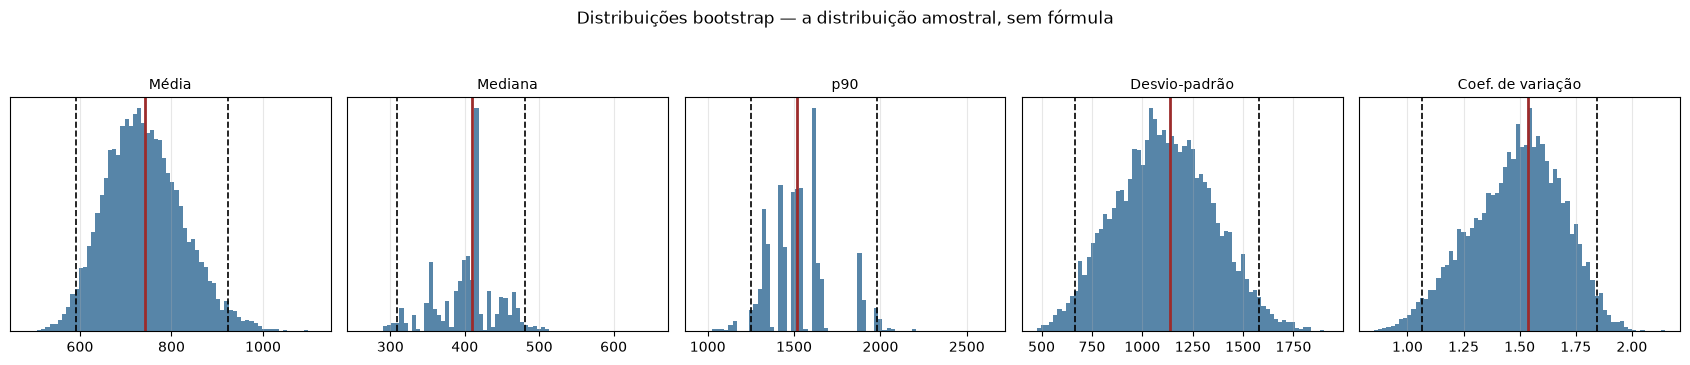

,valor observado,EP bootstrap,"IC 2,5%","IC 97,5%",largura relativa
estatística,,,,,
Média,741.541,84.567,591.114,922.821,0.447
Mediana,409.356,42.995,309.459,480.776,0.419
p90,1517.385,183.411,1250.561,1980.987,0.481
Desvio-padrão,1139.409,239.762,664.251,1579.897,0.804
Coef. de variação,1.537,0.204,1.065,1.843,0.506


In [4]:
# Uma amostra realista: receita mensal por cliente (log-normal, cauda longa)
amostra = rng.lognormal(mean=np.log(420), sigma=1.15, size=180)

def bootstrap(amostra, estatistica, B=10_000, semente=0):
    """Reamostra com reposição B vezes e aplica a estatística em cada réplica."""
    r = np.random.default_rng(semente)
    n = len(amostra)
    # Sorteia B×n índices de uma vez — muito mais rápido que um laço
    indices = r.integers(0, n, size=(B, n))
    return estatistica(amostra[indices], axis=1)


estatisticas = {
    "Média": lambda a, axis: a.mean(axis=axis),
    "Mediana": lambda a, axis: np.median(a, axis=axis),
    "p90": lambda a, axis: np.percentile(a, 90, axis=axis),
    "Desvio-padrão": lambda a, axis: a.std(axis=axis, ddof=1),
    "Coef. de variação": lambda a, axis: a.std(axis=axis, ddof=1) / a.mean(axis=axis),
}

fig, axes = plt.subplots(1, 5, figsize=(17, 3.4))
resumo = []
for ax, (nome, f) in zip(axes, estatisticas.items()):
    replicas = bootstrap(amostra, f)
    obs = f(amostra[None, :], axis=1)[0]
    lo, hi = np.percentile(replicas, [2.5, 97.5])
    ax.hist(replicas, bins=70, color=AZUL, alpha=0.75, edgecolor="none")
    ax.axvline(obs, color=VERMELHO, lw=2)
    ax.axvline(lo, color="black", ls="--", lw=1.2)
    ax.axvline(hi, color="black", ls="--", lw=1.2)
    ax.set_title(nome, fontsize=10)
    ax.set_yticks([])
    resumo.append({"estatística": nome, "valor observado": obs,
                   "EP bootstrap": replicas.std(ddof=1),
                   "IC 2,5%": lo, "IC 97,5%": hi,
                   "largura relativa": (hi - lo) / obs})
plt.suptitle("Distribuições bootstrap — a distribuição amostral, sem fórmula", y=1.06)
plt.tight_layout()
plt.show()

pd.DataFrame(resumo).set_index("estatística").round(3)

Repare na coluna `largura relativa`: o p90 e o coeficiente de variação têm
incerteza **muito** maior que a mediana. Isso é informação que nenhuma
estimativa pontual revelaria — e é a razão de reportar p90 de amostras pequenas
ser tão traiçoeiro.

## 4. As variantes do bootstrap, e quando cada uma importa

In [5]:
def bootstrap_percentil(amostra, f, B=10_000, semente=0):
    rep = bootstrap(amostra, f, B, semente)
    return np.percentile(rep, [2.5, 97.5])


def bootstrap_bca(amostra, f, B=10_000, semente=0, alpha=0.05):
    """BCa: corrige VIÉS (z0) e ASSIMETRIA/aceleração (a).

    É o padrão recomendado. O percentil simples supõe que a distribuição
    bootstrap é simétrica e centrada — o que é falso para estatísticas
    assimétricas como o p90 ou a variância.
    """
    n = len(amostra)
    obs = f(amostra[None, :], axis=1)[0]
    rep = bootstrap(amostra, f, B, semente)

    # z0: correção de viés — quão deslocada está a distribuição bootstrap
    prop = np.mean(rep < obs)
    prop = np.clip(prop, 1 / B, 1 - 1 / B)
    z0 = stats.norm.ppf(prop)

    # a: aceleração, estimada por jackknife (deixe-um-de-fora)
    idx = np.arange(n)
    jack = np.array([f(amostra[idx != i][None, :], axis=1)[0] for i in range(n)])
    desvio = jack.mean() - jack
    denom = 6 * (np.sum(desvio ** 2) ** 1.5)
    a = np.sum(desvio ** 3) / denom if denom != 0 else 0.0

    z_lo, z_hi = stats.norm.ppf(alpha / 2), stats.norm.ppf(1 - alpha / 2)
    p_lo = stats.norm.cdf(z0 + (z0 + z_lo) / (1 - a * (z0 + z_lo)))
    p_hi = stats.norm.cdf(z0 + (z0 + z_hi) / (1 - a * (z0 + z_hi)))
    return np.percentile(rep, [100 * p_lo, 100 * p_hi])


# Auditoria de cobertura: qual variante realmente entrega 95%?
def auditoria_cobertura(n=60, n_sim=800, B=1500):
    """Simula muitas amostras log-normais e conta quantos ICs contêm a média real."""
    mu_log, sigma_log = np.log(420), 1.15
    media_verdadeira = np.exp(mu_log + sigma_log ** 2 / 2)
    f_media = lambda a, axis: a.mean(axis=axis)

    acertos = {"t clássico": 0, "bootstrap percentil": 0, "bootstrap BCa": 0}
    larguras = {k: [] for k in acertos}
    r = np.random.default_rng(4242)
    for s in range(n_sim):
        am = r.lognormal(mu_log, sigma_log, n)

        tc = stats.t.ppf(0.975, n - 1) * am.std(ddof=1) / np.sqrt(n)
        ic_t = (am.mean() - tc, am.mean() + tc)
        ic_p = tuple(bootstrap_percentil(am, f_media, B=B, semente=s))
        ic_b = tuple(bootstrap_bca(am, f_media, B=B, semente=s))

        for nome, (lo, hi) in [("t clássico", ic_t), ("bootstrap percentil", ic_p),
                               ("bootstrap BCa", ic_b)]:
            acertos[nome] += lo <= media_verdadeira <= hi
            larguras[nome].append(hi - lo)
    return pd.DataFrame({
        "cobertura real": {k: v / n_sim for k, v in acertos.items()},
        "largura média": {k: np.mean(v) for k, v in larguras.items()},
    })


print("AUDITORIA — média de uma log-normal fortemente assimétrica, n = 60")
print("(a média verdadeira é conhecida; contamos quantos ICs a capturam)\n")
audit = auditoria_cobertura()
print(audit.round(4).to_string())
print("\nNominal: 95,0%")

AUDITORIA — média de uma log-normal fortemente assimétrica, n = 60
(a média verdadeira é conhecida; contamos quantos ICs a capturam)



                     cobertura real  largura média
t clássico                   0.8675       621.5516
bootstrap percentil          0.8712       594.0157
bootstrap BCa                0.8850       670.9008

Nominal: 95,0%


Nenhum dos três atinge 95% exatos — porque a log-normal é **muito** assimétrica
e $n = 60$ é pouco (lembre do notebook do TLC). Mas o BCa é o que chega mais
perto, corrigindo justamente a assimetria que derruba os outros dois.

> **Regra prática:** use **BCa** por padrão. Use percentil quando a estatística
> é aproximadamente não-viesada e simétrica (a mediana, por exemplo) e você
> precisa de velocidade.

## 5. Onde o bootstrap quebra: dados dependentes

O bootstrap padrão sorteia **observações individuais**, o que destrói qualquer
estrutura de dependência. Em séries temporais isso produz intervalos
absurdamente estreitos.

In [6]:
# Série AR(1): cada valor depende do anterior — autocorrelação forte
n_serie, phi = 400, 0.85
ruido = rng.normal(0, 1, n_serie)
serie = np.zeros(n_serie)
for t in range(1, n_serie):
    serie[t] = phi * serie[t - 1] + ruido[t]

def bootstrap_blocos(x, f, tamanho_bloco, B=5_000, semente=0):
    """Reamostra BLOCOS contíguos, preservando a dependência local."""
    r = np.random.default_rng(semente)
    n = len(x)
    n_blocos = int(np.ceil(n / tamanho_bloco))
    inicios = r.integers(0, n - tamanho_bloco + 1, size=(B, n_blocos))
    desloc = np.arange(tamanho_bloco)
    idx = (inicios[:, :, None] + desloc[None, None, :]).reshape(B, -1)[:, :n]
    return f(x[idx], axis=1)

f_media = lambda a, axis: a.mean(axis=axis)
rep_iid = bootstrap(serie, f_media, B=5_000)
larguras = {"bootstrap i.i.d. (ERRADO)": np.percentile(rep_iid, [2.5, 97.5])}
for bloco in [5, 20, 50]:
    rep = bootstrap_blocos(serie, f_media, bloco, B=5_000)
    larguras[f"bootstrap por blocos (tam={bloco})"] = np.percentile(rep, [2.5, 97.5])

# Referência: erro-padrão TEÓRICO da média de um AR(1)
# Var(média) ≈ σ²/n · (1+φ)/(1-φ)
var_ruido = 1.0
var_serie = var_ruido / (1 - phi ** 2)
ep_teorico = np.sqrt(var_serie / n_serie * (1 + phi) / (1 - phi))
larguras["TEÓRICO correto (AR1)"] = (serie.mean() - 1.96 * ep_teorico,
                                     serie.mean() + 1.96 * ep_teorico)

print(f"Autocorrelação de defasagem 1 da série: "
      f"{np.corrcoef(serie[:-1], serie[1:])[0,1]:.3f}\n")
print(f"{'método':38s} {'IC 95%':>26s} {'largura':>10s}")
print("-" * 78)
for nome, (lo, hi) in larguras.items():
    print(f"{nome:38s} [{lo:>8.3f}, {hi:>8.3f}] {hi-lo:>10.3f}")

print("\nO bootstrap i.i.d. produz um intervalo VÁRIAS VEZES estreito demais.")
print("Ele acredita ter 400 observações independentes; na prática tem muito menos.")

Autocorrelação de defasagem 1 da série: 0.857

método                                                     IC 95%    largura
------------------------------------------------------------------------------
bootstrap i.i.d. (ERRADO)              [  -0.167,    0.211]      0.378
bootstrap por blocos (tam=5)           [  -0.356,    0.416]      0.772
bootstrap por blocos (tam=20)          [  -0.547,    0.456]      1.003
bootstrap por blocos (tam=50)          [  -0.539,    0.403]      0.942
TEÓRICO correto (AR1)                  [  -0.629,    0.677]      1.307

O bootstrap i.i.d. produz um intervalo VÁRIAS VEZES estreito demais.
Ele acredita ter 400 observações independentes; na prática tem muito menos.


> **Este é um dos erros mais comuns e mais invisíveis em análise de produto.**
> Dados de usuários com múltiplas sessões, séries temporais, dados espaciais,
> medidas repetidas — em todos, o bootstrap i.i.d. superestima o tamanho
> efetivo da amostra e produz certeza fabricada. A correção é reamostrar a
> **unidade independente** (o usuário inteiro, o bloco temporal), não a linha.

## 6. Tamanho de amostra: planejando antes de coletar

In [7]:
def n_necessario_proporcao(margem, p_esperado=0.5, confianca=0.95):
    z = stats.norm.ppf(1 - (1 - confianca) / 2)
    return int(np.ceil(z ** 2 * p_esperado * (1 - p_esperado) / margem ** 2))

print("Tamanho de amostra para estimar uma proporção (pior caso, p = 0,5):\n")
print(f"{'margem de erro':>16s} {'n necessário':>14s}")
print("-" * 32)
for margem in [0.10, 0.05, 0.03, 0.02, 0.01, 0.005]:
    print(f"{margem:>15.1%} {n_necessario_proporcao(margem):>14,d}")

print("\nRepare: reduzir a margem pela metade QUADRUPLICA o n.")
print("É a economia do √n vista pelo avesso — e é por isso que")
print("pesquisas eleitorais param nos ~1.000 entrevistados (margem de 3 p.p.).")

Tamanho de amostra para estimar uma proporção (pior caso, p = 0,5):

  margem de erro   n necessário
--------------------------------
          10.0%             97
           5.0%            385
           3.0%          1,068
           2.0%          2,401
           1.0%          9,604
           0.5%         38,415

Repare: reduzir a margem pela metade QUADRUPLICA o n.
É a economia do √n vista pelo avesso — e é por isso que
pesquisas eleitorais param nos ~1.000 entrevistados (margem de 3 p.p.).


## 7. Exercícios

1. Refaça a seção 1 com $n = 5$ e com uma população **log-normal**. A cobertura
   ainda é 95%? Relacione com o notebook do TLC.
2. Implemente o **bootstrap-t** (estudentizado) e adicione-o à auditoria da
   seção 4. Ele costuma ter a melhor cobertura — a que custo computacional?
3. Use bootstrap para o **IC da diferença entre duas medianas** de dois grupos.
   Cuidado: reamostre cada grupo separadamente, preservando os tamanhos.
4. Na seção 5, encontre o tamanho de bloco que reproduz o IC teórico. Existe
   uma regra prática: $\ell \approx n^{1/3}$. Ela funciona aqui?
5. Simule dados agrupados (100 usuários × 20 sessões cada) e compare bootstrap
   por linha vs. bootstrap por usuário. Quanto o primeiro subestima o IC?

## Próximo módulo

`04-testes-de-hipotese/` — a outra metade da inferência: decidir, com uma
régua explícita para a taxa de erro que você aceita.